## EDA

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [51]:
df=pd.read_csv('../app/cleaned_stress_survey.csv')
df.head()

,Gender,Year,Branch,CGPA,Sleep_Hours,Screen_Time,Exercise_Freq,Diet_Quality,Study_Hours,Stress_Factors,GAD_Nervous,GAD_Irritable,Coping_Method,Counsellor_Need,Overall_Stress,College_Support,Programme,College Type
0,Female,1st Yr,MSME,Above 9.0,6 - 8 hours,1 - 3 hours,1 - 2 times a week,Very poor (mostly junk/irregular),2 - 4 hours,"Attendance pressure, Career and placement anxi...",2,3,"Talking to friends or family, Listening to mus...",No,4,"Yes, very much",B.Tech,IIT
1,Male,2nd Yr,CSE / IT,6.0 - 7.0,6 - 8 hours,3 - 5 hours,Daily,Average,Less than 2 hours,"Exams and assignments, Career and placement an...",1,1,"Exercise or sports, Sleeping it off, Ignoring/...",No,7,Somewhat,B.Tech,IIT
2,Male,2nd Yr,DSAI,8.0 - 9.0,6 - 8 hours,More than 5 hours,3 - 4 times a week,Good,2 - 4 hours,"Exams and assignments, Attendance pressure, La...",3,3,"Listening to music / watching content, Exercis...","Yes, and I did seek help",9,Somewhat,B.Tech,IIT
3,Male,2nd Yr,CSE / IT,8.0 - 9.0,4 - 6 hours,1 - 3 hours,Daily,Very good (balanced meals),Less than 2 hours,"Exams and assignments, Peer comparison / compe...",3,3,"Talking to friends or family, Listening to mus...",No,9,Somewhat,B.Tech,IIT
4,Male,2nd Yr,CSE / IT,8.0 - 9.0,6 - 8 hours,3 - 5 hours,1 - 2 times a week,Average,Less than 2 hours,"Exams and assignments, Peer comparison / compe...",2,2,"Talking to friends or family, Exercise or spor...","Yes, but I did not seek help",8,Somewhat,B.Tech,IIT


Firstly we will look at the respondents who filled the form by answering few questions related to them . 

In [52]:
df.drop(columns=['Programme','College Type'],inplace=True)
df['Stress_Level']=df['Overall_Stress'].apply(lambda x: 'Low' if x<=3 else('Medium' if x<=6 else 'High'))

In [53]:
df.head(5)

,Gender,Year,Branch,CGPA,Sleep_Hours,Screen_Time,Exercise_Freq,Diet_Quality,Study_Hours,Stress_Factors,GAD_Nervous,GAD_Irritable,Coping_Method,Counsellor_Need,Overall_Stress,College_Support,Stress_Level
0,Female,1st Yr,MSME,Above 9.0,6 - 8 hours,1 - 3 hours,1 - 2 times a week,Very poor (mostly junk/irregular),2 - 4 hours,"Attendance pressure, Career and placement anxi...",2,3,"Talking to friends or family, Listening to mus...",No,4,"Yes, very much",Medium
1,Male,2nd Yr,CSE / IT,6.0 - 7.0,6 - 8 hours,3 - 5 hours,Daily,Average,Less than 2 hours,"Exams and assignments, Career and placement an...",1,1,"Exercise or sports, Sleeping it off, Ignoring/...",No,7,Somewhat,High
2,Male,2nd Yr,DSAI,8.0 - 9.0,6 - 8 hours,More than 5 hours,3 - 4 times a week,Good,2 - 4 hours,"Exams and assignments, Attendance pressure, La...",3,3,"Listening to music / watching content, Exercis...","Yes, and I did seek help",9,Somewhat,High
3,Male,2nd Yr,CSE / IT,8.0 - 9.0,4 - 6 hours,1 - 3 hours,Daily,Very good (balanced meals),Less than 2 hours,"Exams and assignments, Peer comparison / compe...",3,3,"Talking to friends or family, Listening to mus...",No,9,Somewhat,High
4,Male,2nd Yr,CSE / IT,8.0 - 9.0,6 - 8 hours,3 - 5 hours,1 - 2 times a week,Average,Less than 2 hours,"Exams and assignments, Peer comparison / compe...",2,2,"Talking to friends or family, Exercise or spor...","Yes, but I did not seek help",8,Somewhat,High


# QUESTIONS

#### Q1. What is the gender and branch profile of respondents?

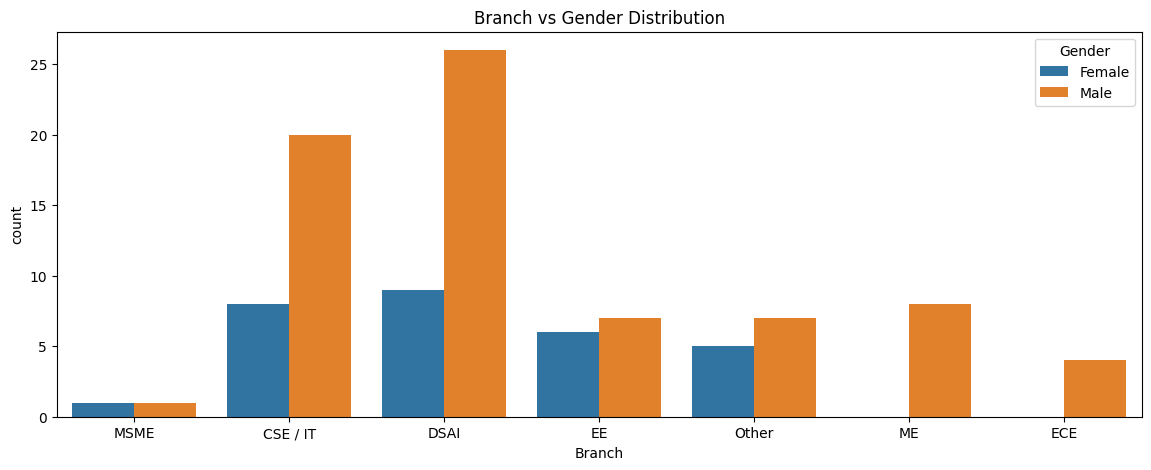

In [75]:
plt.figure(figsize=(14,5))
sns.countplot(x='Branch', hue='Gender', data=df)
plt.title("Branch vs Gender Distribution")
plt.show()

We can clearly see majority of the respondents are Male and few are female  and most of the people belong to dsai branch

#### Q2. Which year dominates and what does that tell us?

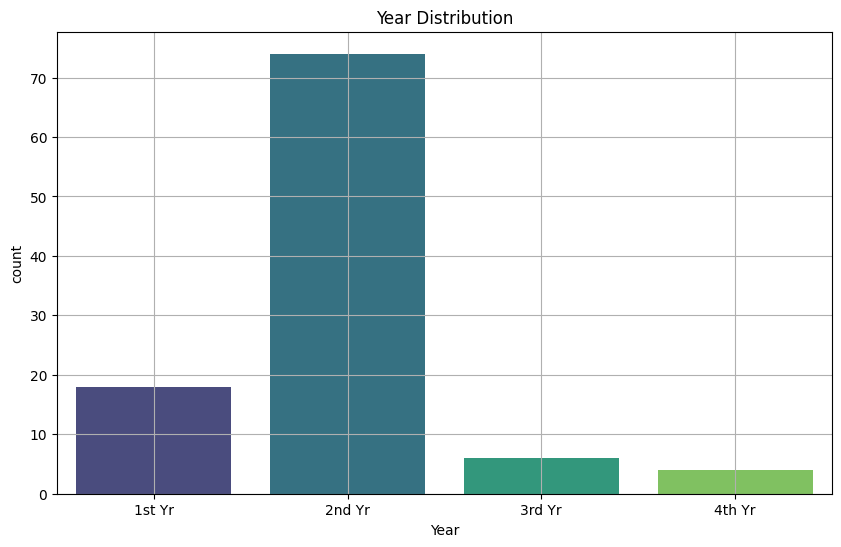

In [55]:
plt.figure(figsize=(10,6))
sns.countplot(x='Year',data=df,palette='viridis')
plt.title('Year Distribution')
plt.grid(True)

74 out of 102 respondents are from 2nd Year, making this study effectively representative of sophomore stress at IIT.

## Now let us look upon questions related to stress

#### Q3. What is the overall stress distribution — and what does the average tell us?

In [56]:
fig = px.histogram(df, x='Overall_Stress',
                   nbins=10,
                   title='Q3 — Overall Stress Score Distribution',
                   labels={'Overall_Stress': 'Stress Score (1-10)'},
                   color_discrete_sequence=["#4FCF78"])

fig.add_vline(x=df['Overall_Stress'].mean(),
              line_dash='dash',
              line_color='red',
              annotation_text=f"Mean = {df['Overall_Stress'].mean():.2f}",
              annotation_position='top right')

fig.update_layout(plot_bgcolor='white',
                  paper_bgcolor='white',
                  bargap=0.1)
fig.show()

42 students (41%) fall in the High stress category (7–10), 34 in Medium (4–6), and 25 in Low (1–3) — indicating academic stress is a significant concern among IIT students.

#### Q4. How do GAD anxiety and irritability scores distribute — and what is the combined GAD score?


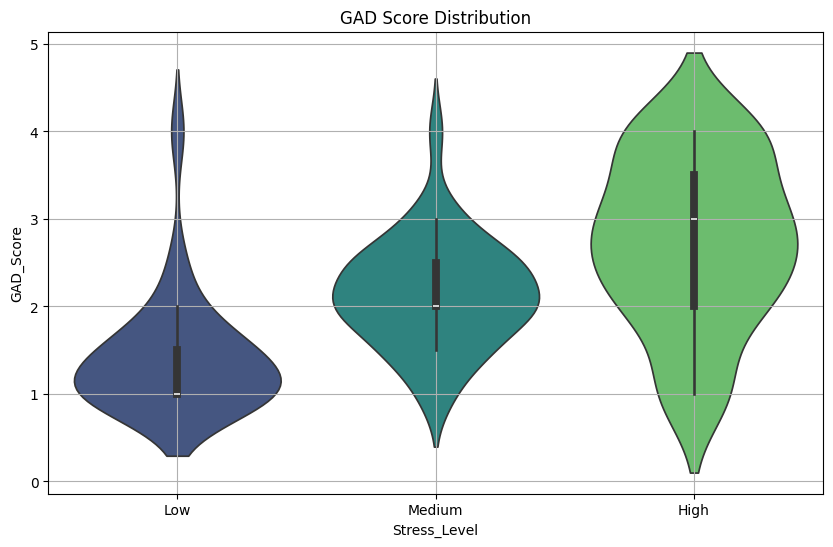

In [57]:
df['GAD_Score']=(df['GAD_Nervous']+df['GAD_Irritable'])/2
plt.figure(figsize=(10,6))
sns.violinplot(x='Stress_Level', y='GAD_Score', data=df,
               order=['Low','Medium','High'], palette='viridis')
plt.title('GAD Score Distribution')
plt.grid(True)
plt.show()

There is a  positive correlation between stress and anxiety, with higher stress levels leading to higher GAD scores.

#### Q5. Do students who sleep less report higher stress — and how strong is this pattern?

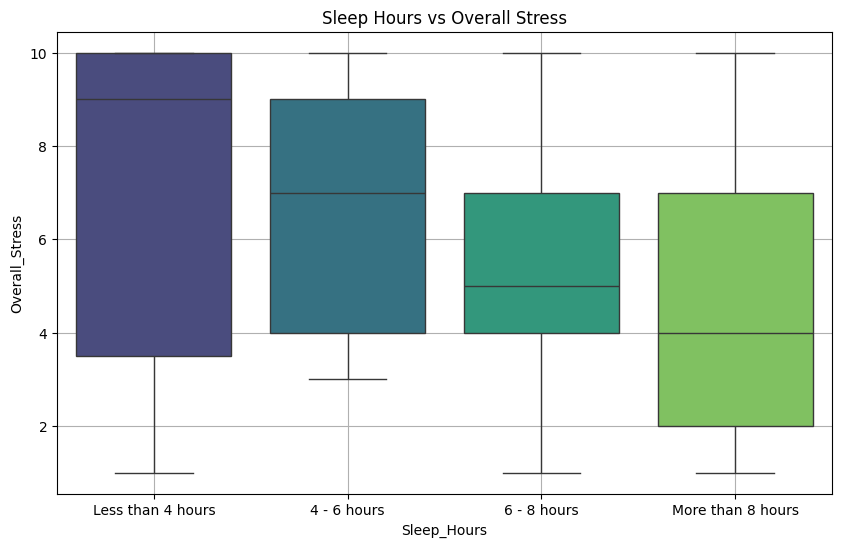

In [58]:
plt.figure(figsize=(10,6))
order=['Less than 4 hours','4 - 6 hours','6 - 8 hours','More than 8 hours']
sns.boxplot(x='Sleep_Hours',y='Overall_Stress',data=df,palette='viridis',order=order)
plt.title('Sleep Hours vs Overall Stress')
plt.grid(True)


Sleep is negatively correlated with stress. It is one of the most influential lifestyle which affects students lifestyle

##### Q6. Does branch affect stress — specifically do DSAI and CSE students stress more than EE and ME or other branch?

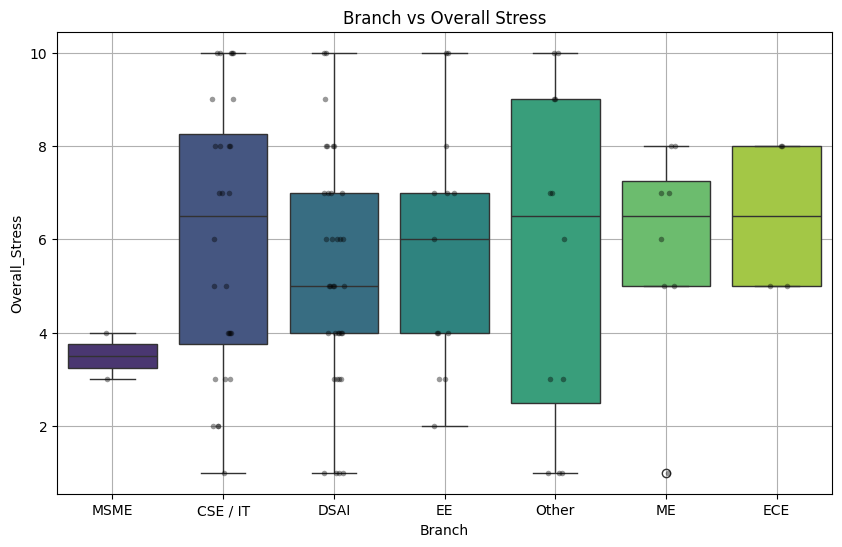

In [59]:
plt.figure(figsize=(10,6))
sns.boxplot(y='Overall_Stress',x='Branch',data=df,palette='viridis')
sns.stripplot(x='Branch', y='Overall_Stress', data=df,
              color='black', alpha=0.4, size=4)
plt.title('Branch vs Overall Stress')
plt.grid(True)
plt.show()

Stress levels are broadly similar across branches, with slight variations, indicating that factors beyond branch likely influence student stress. Stress levels are fairly similar across branches, mostly between 5–7 range

#### Q7. Do high CGPA students stress more or less — does academic performance protect against stress?

In [60]:
cgpa_order = ['Below 6.0','6.0 - 7.0','7.0 - 8.0','8.0 - 9.0','Above 9.0']

fig = px.box(df, x='CGPA', y='Overall_Stress',
             category_orders={'CGPA': cgpa_order},
             color='CGPA',
             title='Q7 — CGPA vs Overall Stress',
             labels={'Overall_Stress': 'Stress Score'},
             points='all',
             color_discrete_sequence=px.colors.qualitative.Set2)

fig.update_layout(showlegend=False,
                  plot_bgcolor='white',
                  paper_bgcolor='white')
fig.show()

Students with lower CGPA tend to experience higher stress, possibly due to academic difficulties. However, even high-performing students exhibit stress, indicating that factors such as expectations, competition, and personal pressure also play a significant role

Q8. Commmon Stress Factors among IIT Students ?

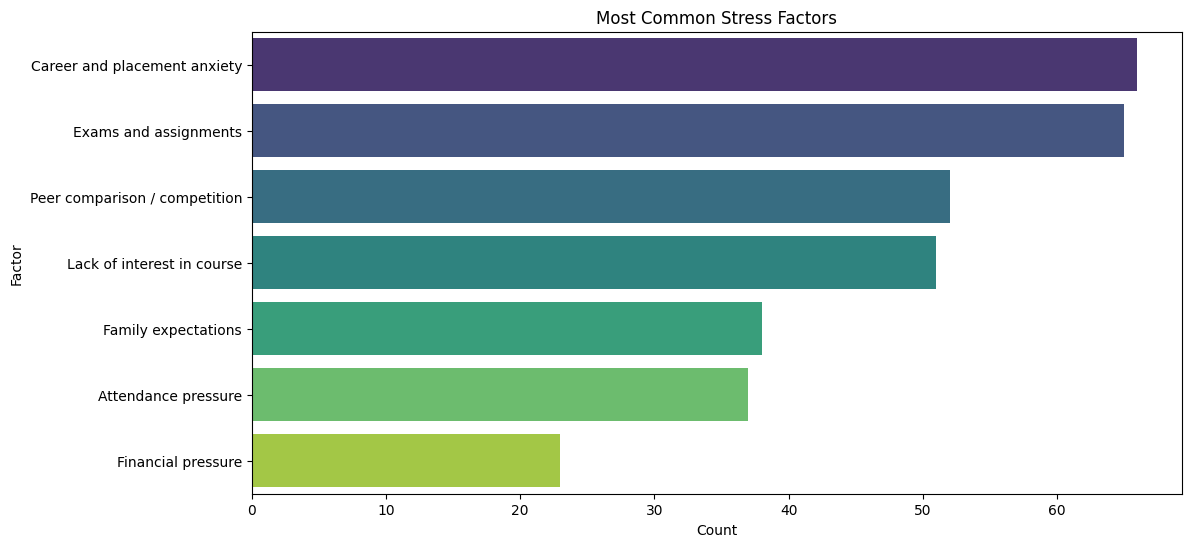

In [61]:
factor_series=df['Stress_Factors'].str.split(',')
from collections import Counter
all_factors = [factor.strip() for sublist in factor_series for factor in sublist]
factor_counts = Counter(all_factors)
factor_df = pd.DataFrame(factor_counts.items(), columns=['Factor', 'Count'])
factor_df = factor_df.sort_values(by='Count', ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x='Count',y='Factor',data=factor_df,palette='viridis')
plt.title('Most Common Stress Factors')
plt.xlabel('Count')
plt.ylabel('Factor')
plt.show()

Most common reason for the stress among students is Career and placement anxiety followed by Exams and assignment . Least common factir is Financial Pressure

Q9. How do lifestyle factors — screen time, exercise frequency, 
diet quality and study hours — relate to overall stress?

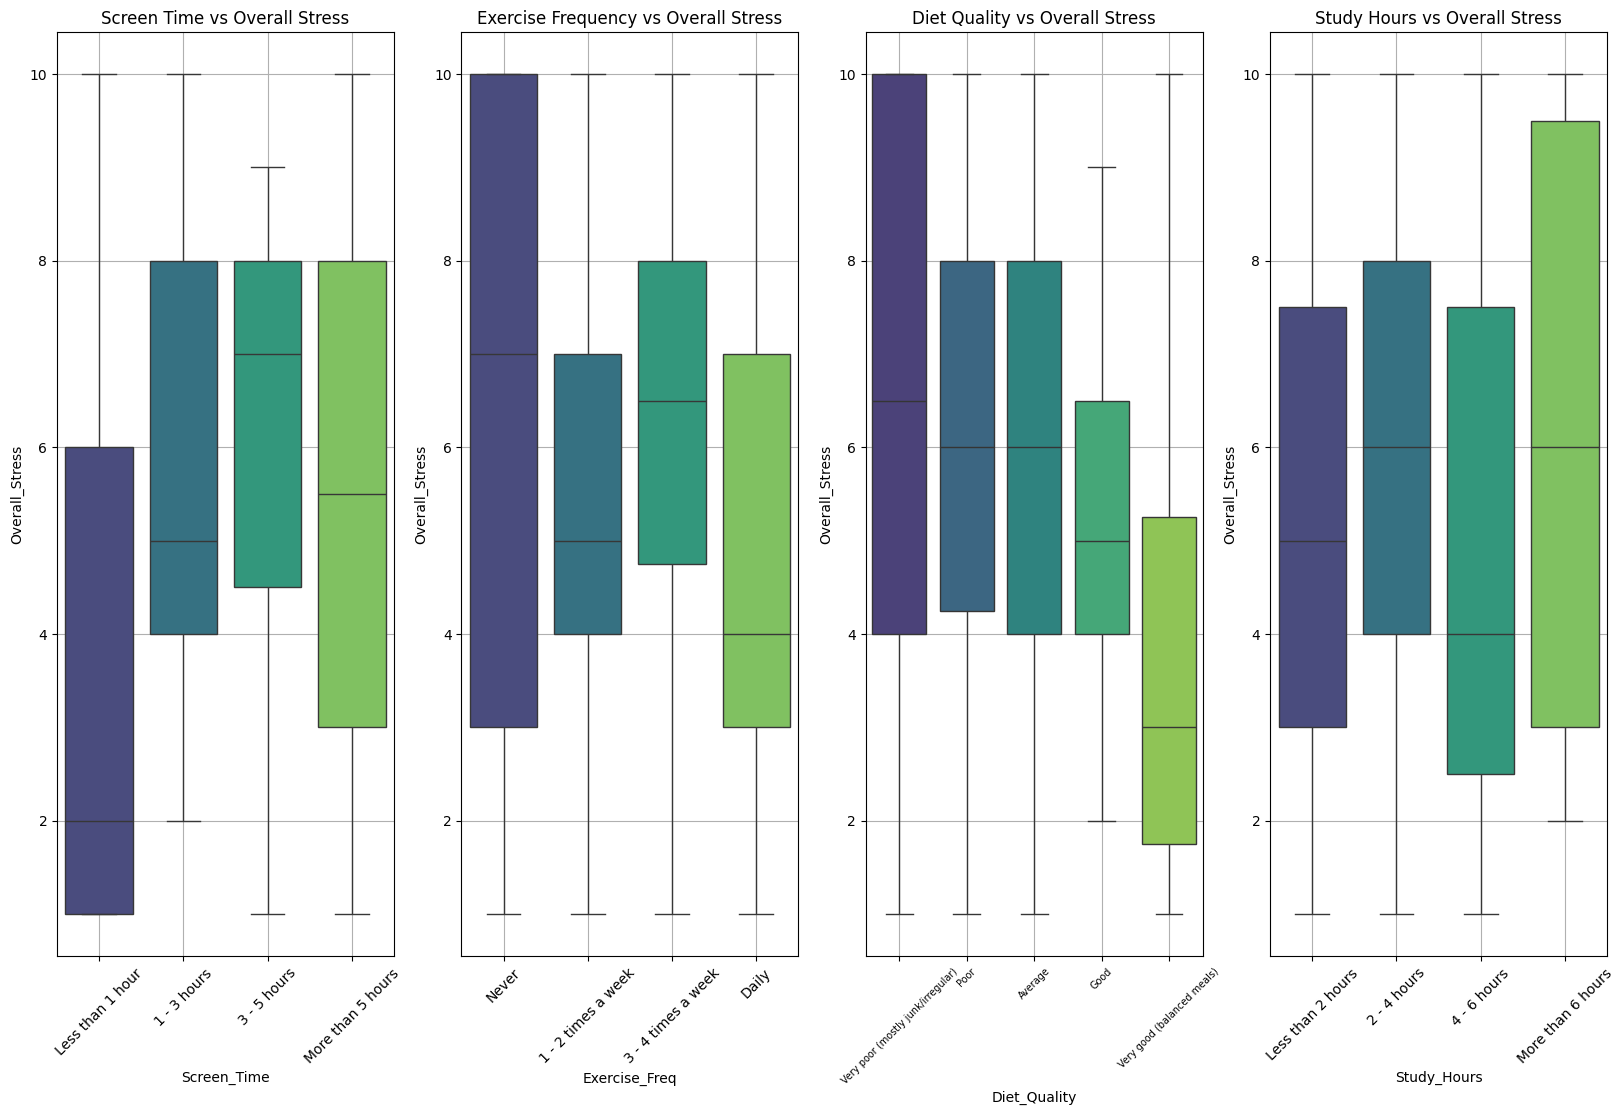

In [62]:
plt.figure(figsize=(20,12))
plt.subplot(1,4,1)
orders=['Less than 1 hour','1 - 3 hours','3 - 5 hours','More than 5 hours']
sns.boxplot(y='Overall_Stress',x='Screen_Time',data=df,palette='viridis',order=orders)
plt.title('Screen Time vs Overall Stress')
plt.xticks(rotation=45)
plt.grid(True)
plt.subplot(1,4,2)
orders=['Never','1 - 2 times a week','3 - 4 times a week','Daily']
sns.boxplot(y='Overall_Stress',x='Exercise_Freq',data=df,palette='viridis',order=orders)
plt.title('Exercise Frequency vs Overall Stress')
plt.xticks(rotation=45)
plt.grid(True)
plt.subplot(1,4,3)
orders=['Very poor (mostly junk/irregular)','Poor','Average','Good','Very good (balanced meals)']
sns.boxplot(y='Overall_Stress',x='Diet_Quality',data=df,palette='viridis',order=orders)
plt.title('Diet Quality vs Overall Stress')
plt.xticks(rotation=45,fontsize=7)
plt.grid(True)
plt.subplot(1,4,4)
orders=['Less than 2 hours','2 - 4 hours','4 - 6 hours','More than 6 hours']
sns.boxplot(y='Overall_Stress',x='Study_Hours',data=df,palette='viridis',order=orders)
plt.title('Study Hours vs Overall Stress')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Lifestyle factors such as screen time, exercise, and diet show a strong influence on stress levels. Students with healthier habits tend to have significantly lower stress. In contrast, study hours show a non-linear relationship, suggesting that balance rather than intensity is key.

Q10: Counselling need vs action — and its relation to stress 

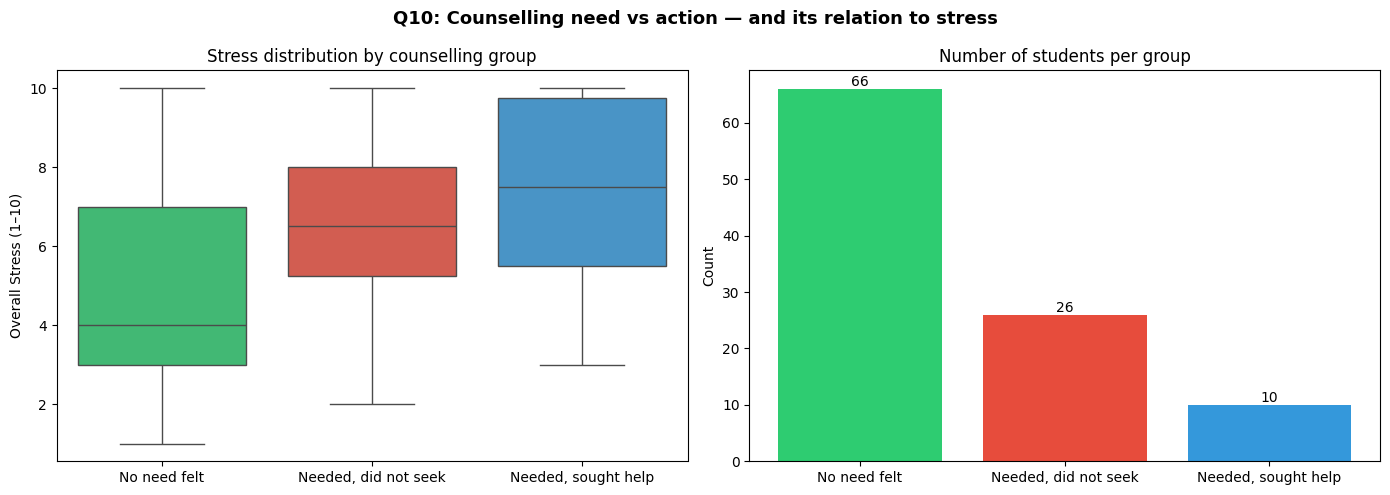

In [63]:
counsellor_map = {
    'No'                           : 'No need felt',
    'Yes, but I did not seek help' : 'Needed, did not seek',
    'Yes, and I did seek help'     : 'Needed, sought help'
}
df['Counsellor_Group'] = df['Counsellor_Need'].map(counsellor_map)

group_order = ['No need felt', 'Needed, did not seek', 'Needed, sought help']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x='Counsellor_Group',
    y='Overall_Stress',
    order=group_order,
    palette=['#2ecc71', '#e74c3c', '#3498db'],
    ax=axes[0]
)
axes[0].set_title('Stress distribution by counselling group')
axes[0].set_xlabel('')
axes[0].set_ylabel('Overall Stress (1–10)')

count_data = df['Counsellor_Group'].value_counts().reindex(group_order)
axes[1].bar(group_order, count_data.values,
            color=['#2ecc71', '#e74c3c', '#3498db'])
axes[1].set_title('Number of students per group')
axes[1].set_ylabel('Count')
for i, v in enumerate(count_data.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.suptitle('Q10: Counselling need vs action — and its relation to stress',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Most of the people did not feel need of counsellor help. 36 out of 102 felt need for counsellor help but only 10 of them really sought help

## Encoding of columns

In [64]:
encoded_df=df.copy()
sleep_map={
    'Less than 4 hours' : 1,
    '4 - 6 hours'      : 2,
    '6 - 8 hours'      : 3,
    'More than 8 hours' : 4 
}
encoded_df['Sleep_Hours']=df['Sleep_Hours'].map(sleep_map)
screen_map={
    'Less than 1 hour' : 1,
    '1 - 3 hours'      : 2,
    '3 - 5 hours'      : 3,
    'More than 5 hours' : 4
}
encoded_df['Screen_Time']=df['Screen_Time'].map(screen_map)
exercise_map={
    'Never'                : 1,
    '1 - 2 times a week'   : 2,
    '3 - 4 times a week'   : 3,
    'Daily'                : 4
}
encoded_df['Exercise_Freq']=df['Exercise_Freq'].map(exercise_map)
diet_map={
    'Very poor (mostly junk/irregular)' : 1,
    'Poor'                          : 2,
    'Average'                            : 3,
    'Good'                               : 4,
    'Very good (balanced meals)'         : 5
}
encoded_df['Diet_Quality']=df['Diet_Quality'].map(diet_map)
study_map={
    'Less than 2 hours' : 1,
    '2 - 4 hours'      : 2,
    '4 - 6 hours'      : 3,
    'More than 6 hours' : 4
}
encoded_df['Study_Hours']=df['Study_Hours'].map(study_map)
encoded_df['CGPA']=encoded_df['CGPA'].map({
    'Below 6.0' : 1,
    '6.0 - 7.0' : 2,
    '7.0 - 8.0' : 3,
    '8.0 - 9.0' : 4,
    'Above 9.0' : 5
})
encoded_df['Overall_Stress']=encoded_df['Overall_Stress'].astype(int)



In [65]:
cols_to_check = ['Sleep_Hours', 'Screen_Time', 'Exercise_Freq',
                 'Diet_Quality', 'Study_Hours', 'CGPA']
print(encoded_df[cols_to_check].isnull().sum())

Sleep_Hours      0
Screen_Time      0
Exercise_Freq    0
Diet_Quality     0
Study_Hours      0
CGPA             0
dtype: int64


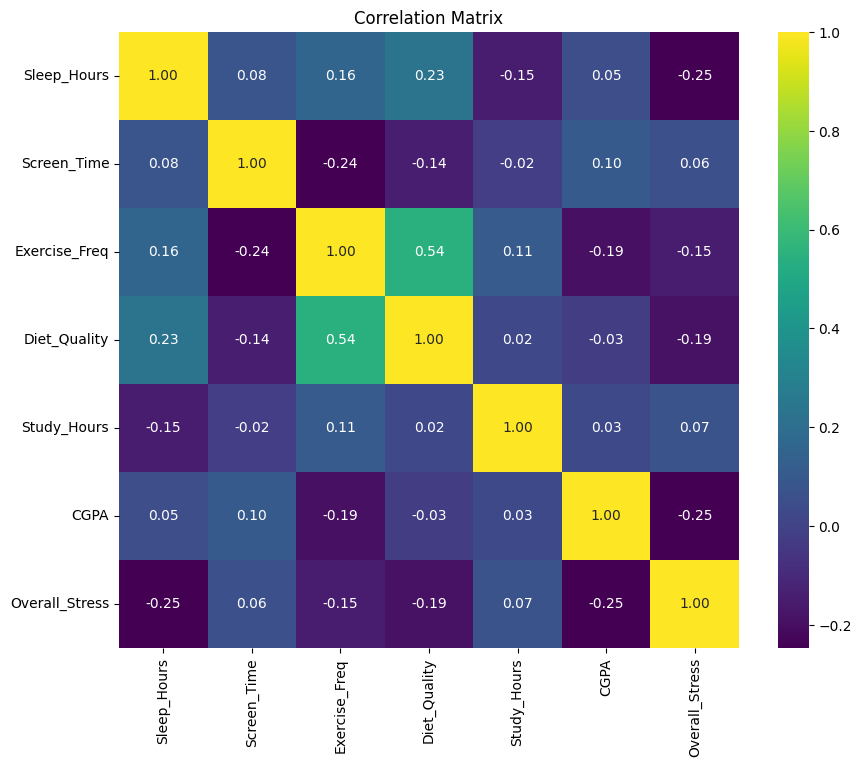

In [66]:
cols=['Sleep_Hours', 'Screen_Time', 'Exercise_Freq',
      'Diet_Quality', 'Study_Hours', 'CGPA','Overall_Stress']
corr=encoded_df[cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Sleep Hours and CGPA have relatively higher correlations with Overall_Stress

In [67]:
encoded_df['Stress_Level']=encoded_df['Overall_Stress'].apply(lambda x: 'Low' if x<=3 else('Medium' if x<=6 else 'High'))

In [68]:
model_cols = [
    'Sleep_Hours', 'Screen_Time', 'Exercise_Freq',
    'Diet_Quality', 'Study_Hours', 'CGPA',
    'GAD_Nervous', 'GAD_Irritable', 'GAD_Score',
    'Overall_Stress', 'Stress_Level'
]

encoded_df[model_cols].to_csv('../Model/model_ready.csv', index=False)